# Final Project - Deep Learning for Computer Vision

#### General Objective
Design and develop, in pairs, a computer-vision solution based on deep learning techniques. The project must cover the full workflow: data collection, model training, result evaluation, and presentation of conclusions. Technical quality, critical reflection, and the ability to solve real-world problems are especially valued.

#### Topic
For this project, we decided to build a segmentation pipeline using medical images.

We use [CHAOS (Combined CT-MR Healthy Abdominal Organ Segmentation)](https://www.kaggle.com/datasets/omarxadel/chaos-combined-ct-mr-healthy-abdominal-organ) as the dataset. It includes both computed tomography (CT) scans and magnetic resonance imaging (MRI) for abdominal organs. Both image sets include masks for detecting and segmenting organs in the abdominal region.

## 0. Utilities

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# BASE_PATH = '/content'
BASE_PATH = '/content/drive/MyDrive/UPM'

Mounted at /content/drive


In [ ]:
%%capture
!pip install pydicom
!pip install pytorch_lightning
!pip install ultralytics

In [ ]:
# Basics
import kagglehub
import os
import pandas as pd
import numpy as np
import gc

# Images
import cv2
import pydicom as dicom
import matplotlib.pyplot as plt

# DataModule
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning import LightningDataModule, seed_everything
from torchvision.transforms import v2
from torchvision.tv_tensors import Image, Mask, BoundingBoxes
from torchvision.ops import masks_to_boxes, batched_nms

# Module
import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import AdamW
from pytorch_lightning import LightningModule, Trainer, Callback
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from ultralytics import YOLO

SEED = 42
seed_everything(SEED, workers=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
class PlotCallback(Callback):
  '''
  Plot losses once training finishes
  '''
  def __init__(self):
    super().__init__()
    # Prepare history
    self.losses = {}

  def on_train_epoch_end(self, trainer, _pl_module):
    # Store values by epoch
    for key, value in trainer.callback_metrics.items():
      loss_name = key.replace('train_', '').replace('val_', '')
      if loss_name not in self.losses:
        self.losses[loss_name] = {}

      if key.startswith('train_'):
        self.losses[loss_name].setdefault('train', []).append(value.item())
      elif key.startswith('val_'):
        self.losses[loss_name].setdefault('val', []).append(value.item())

  def on_fit_end(self, _trainer, _pl_module):
    # Plot loss history
    num_losses = len(self.losses)
    num_rows = num_losses // 3 + 1 if num_losses % 3 != 0 else num_losses // 3
    num_columns = min(3, num_losses)

    _, axes = plt.subplots(num_rows, num_columns, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for (loss_name, losses), ax in zip(self.losses.items(), axes):
      ax.plot(losses['train'], label='Training')
      ax.plot(losses['val'], label='Validation')
      ax.set_xlabel('Epochs')
      ax.set_ylabel(loss_name.replace('_', ' ').title())
      ax.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
class ModuleEvaluator():
  '''
  Evaluate models using the Dice coefficient
  '''
  def __init__(self, model: LightningDataModule | nn.Module, model_type: str = 'semantic', num_classes: int = 5):
    self.model = model
    self.model_type = model_type
    self.num_classes = 5
    self.labels = {
      1: 'Liver',
      2: 'Right Kidney',
      3: 'Left Kidney',
      4: 'Spleen'
    }

  def evaluate(self, dataloader: DataLoader, instance_threshold: float = 0.8):
    self.instance_threshold = instance_threshold
    self.model.eval()

    all_preds = []
    all_masks = []

    with torch.no_grad():
      for images, targets in dataloader:
        images = images.to(self.model.device)

        # Transform instance masks into semantic masks
        semantic_masks = self._from_target_to_semantic(targets) # (B, H, W)

        # Semantic models such as UNet return (B, Classes, H, W)
        if self.model_type == 'semantic':
          logits = self.model(images)
          probs = logits.argmax(dim=1) # (B, H, W)

        # Instance models such as Mask R-CNN return a list (N, ) de diccionarios
        elif self.model_type == 'instance':
          results = self.model(images)
          probs = self._from_instance_to_semantic(results) # (B, H, W)

        all_masks.append(semantic_masks)
        all_preds.append(probs)

    all_masks = torch.cat(all_masks)
    all_preds = torch.cat(all_preds)

    return self._calculate_metrics(all_masks, all_preds)

  def plot_predictions(self, dataset: Dataset, instance_threshold: float = 0.8, num_samples: int = 5):
    self.instance_threshold = instance_threshold
    self.model.eval()

    samples = np.random.randint(0, len(dataset), num_samples)
    fig, ax = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i, sample_index in enumerate(samples):
      image, target = dataset[sample_index]

      image = image.unsqueeze(0).to(self.model.device)

      with torch.no_grad():
        if self.model_type == 'semantic':
          logits = self.model(image)  # (B, Classes, H, W) - Incluye Background con valores logits
          pred = logits.argmax(dim=1).cpu() # (B, H, W)

          # Create bounding boxes (B, Classes, H, W) - Incluye Background con valores binarios (1 o 0)
          one_hot_pred = F.one_hot(pred, num_classes=self.num_classes).permute(0, 3, 1, 2)
          # Filter detected instances
          instance_masks = [instance_mask for instance_mask in one_hot_pred.squeeze()[1:] if instance_mask.sum() > 0]
          if len(instance_masks) > 0:
            instance_masks = torch.stack(instance_masks)
            bboxes = BoundingBoxes(masks_to_boxes(instance_masks), dtype=torch.float32, format="XYXY", canvas_size=pred.shape[-2:])
          else:
            bboxes = []

        elif self.model_type == 'instance':
          results = self.model(image) # List of dictionaries
          # Convert instance masks into a single semantic mask
          pred = self._from_instance_to_semantic(results).cpu()
          # Build bounding boxes
          bboxes = results[0]['boxes'][results[0]['scores'] > self.instance_threshold].cpu()

        ax[i, 0].imshow(image.cpu().squeeze(), cmap='gray')
        ax[i, 0].set_title('Image')
        ax[i, 0].axis('off')

        if len(bboxes) > 0:
          for box in bboxes:
            rect = plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                fill=False, edgecolor='red', linewidth=2)
            ax[i, 0].add_patch(rect)

        # Reconstruct the mask
        mask = self._from_target_to_semantic([target]).cpu()
        ax[i, 1].imshow(mask.squeeze(), cmap='gray')
        ax[i, 1].set_title('Mask')
        ax[i, 1].axis('off')

        ax[i, 2].imshow(pred.squeeze(), cmap='gray')
        ax[i, 2].set_title('Prediction')
        ax[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

  def _to_semantic(callable):
    def wrapper(self, to_transform: list):
      batch_size = len(to_transform)
      H, W = to_transform[0]['masks'].shape[-2:]

      semantic_masks = torch.zeros(batch_size, H, W, dtype=torch.long, device=self.model.device)
      for i in range(batch_size):
        masks, labels = callable(self, to_transform[i])

        for j, (label, mask) in enumerate(zip(labels, masks)):
          semantic_masks[i][mask == 1] = label

      return semantic_masks
    return wrapper

  @_to_semantic
  def _from_target_to_semantic(self, target: dict) -> torch.Tensor:
    return target['masks'], target['labels']

  @_to_semantic
  def _from_instance_to_semantic(self, result: list) -> torch.Tensor:
    scores = result['scores']
    masks = result['masks'][scores > self.instance_threshold].squeeze(1)
    masks = (masks > self.instance_threshold).float()
    labels = result['labels'][scores > self.instance_threshold]

    return masks, labels

  def _calculate_metrics(self, masks: torch.Tensor, preds: torch.Tensor) -> dict:
    metrics = {}

    one_hot_mask = F.one_hot(masks, num_classes=self.num_classes).permute(0, 3, 1, 2) # (B, Classes, H, W)
    one_hot_pred = F.one_hot(preds, num_classes=self.num_classes).permute(0, 3, 1, 2)

    dims = (0, 2, 3)
    intersection = (one_hot_pred * one_hot_mask).sum(dims)
    union  = (one_hot_pred + one_hot_mask).sum(dims)
    dice_per_ch  = 2 * (intersection + 1e-6) / (union + 1e-6) # (Classes,)
    dice_per_ch = dice_per_ch[1:] # Ignore background
    for i, ch in enumerate(dice_per_ch):
      metrics[f'Dice Coef {self.labels[i + 1]}'] = ch.item()
    metrics['Mean Dice Coef'] = dice_per_ch.mean().item()

    return metrics

## 1. Dataset

### 1.1 General Information

We can download the dataset directly from Kaggle using `kagglehub`. It is important to note that the test set does not include masks, so it cannot be used to evaluate model performance. We therefore need to split the training set into train, validation, and test subsets, while limiting the amount of data used for training.

In [ ]:
kagglehub.dataset_download(
  'omarxadel/chaos-combined-ct-mr-healthy-abdominal-organ',
  force_download=True,
  output_dir='/content/dataset'
)

if not os.path.exists('/content/dataset'):
  if os.path.exists('../kaggle/input/chaos-combined-ct-mr-healthy-abdominal-organ'):
    !cp -r ../kaggle/input/chaos-combined-ct-mr-healthy-abdominal-organ /content/dataset
  else:
    print('There was an error loading the dataset. Please try again.')

100%|██████████| 1.87G/1.87G [00:21<00:00, 94.8MB/s]

Extracting files...


In [ ]:
%cat /content/dataset/CHAOS_Train_Sets/Train_Sets/NOTES_PLEASE_READ.txt

Last update: 1/03/2019

=== CT Sets ===
--All labels of CT sets were reviewed. Some ground truth data might be slightly different from the first published set. Please use the last version of the sets.
--All distinguishable "vena cava inferior" areas were excluded from the liver in ground truth data.
--All gallbladder "vena cava inferior" areas were excluded from the liver in ground truth data.
--Any value grater than zero represents the liver in the ground images.

=== MR Sets ===
--All labels of MR sets were reviewed. Some ground truth data might be slightly different from the first published set. Please use the last version of the sets.
--The In-phase and Out-phase images have same UID in the T1DUAL sequences. Therefore they were stored under two folder.
--The ground images in T1DUAL folder represents both In-phase and Out-phase images.
--The anonymization method of the MR sequences was changed to prevent UID data in DICOM images.
--All distinguishable "vena cava inferior" areas were

The general description of the training set indicates that:
- It was last updated in 2019.
- The CT subset only includes liver segmentation.
- The MRI subset includes labels for liver, kidneys, and spleen, each with its corresponding value range in the mask.

Additionally, the MRI subset is further divided into two folders: T1DUAL and T2SPIR. T1DUAL contains more images because it uses a technique for detecting microscopic fat by comparing InPhase and OutPhase images. T2SPIR does not use this technique, so it reduces the number of images by half. Even so, both folders contain the same number of masks because they analyze the same number of samples.

Given these characteristics, several models could be developed for analyzing and segmenting radiological images. To keep the project scope focused and balanced, we use the MRI - T2SPIR subset, so the model can detect and segment multiple organs while maintaining a 1:1 relationship between image and mask.

### 1.2 Exploratory Data Analysis

Because we are limited to the training set, we need to check how many images are available and whether all of them have masks.

In [ ]:
TRAIN_PATH = '/content/dataset/CHAOS_Train_Sets/Train_Sets/MR'

# Compute the number of patients
patients = [f for f in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, f))]
print(f'Number of patients: {len(patients)}')

# Compute how many images there are per patient
images_per_patient = []
for patient in patients:
  images_path = f'{TRAIN_PATH}/{patient}/T2SPIR/DICOM_anon'
  masks_path = f'{TRAIN_PATH}/{patient}/T2SPIR/Ground'

  images = [f for f in os.listdir(images_path) if os.path.isfile(os.path.join(images_path, f))]
  masks = [f for f in os.listdir(masks_path) if os.path.isfile(os.path.join(masks_path, f))]

  images_per_patient.append({
    'patient': patient,
    'images': len(images),
    'masks': len(masks),
    'image match': len(images) == len(masks)
  })

images_per_patient = pd.DataFrame(images_per_patient).set_index('patient')
display(images_per_patient)

# Total number of images
print(f'\nTotal number of images: {images_per_patient["images"].sum()}')
print(f"Average number of images per patient: {images_per_patient['images'].mean()}")
print(f"Patient with the fewest images: {images_per_patient['images'].min()} (Patient {images_per_patient['images'].idxmin()})")
print(f"Patient with the most images: {images_per_patient['images'].max()} (Patient {images_per_patient['images'].idxmax()})")

Number of patients: 20


,images,masks,image match
patient,,,
8,32,32,True
39,26,26,True
20,26,26,True
10,36,36,True
13,30,30,True
3,30,30,True
31,29,29,True
33,29,29,True
1,36,36,True



Total number of images: 623
Average number of images per patient: 31.15
Patient with the fewest images: 26 (Patient 39)
Patient with the most images: 39 (Patient 32)


There are 20 patients and 623 images in total. Every image has a corresponding mask, although the number of images varies by patient. Patients have a minimum of 26 images and a maximum of 39.

Image shape: (256, 256)


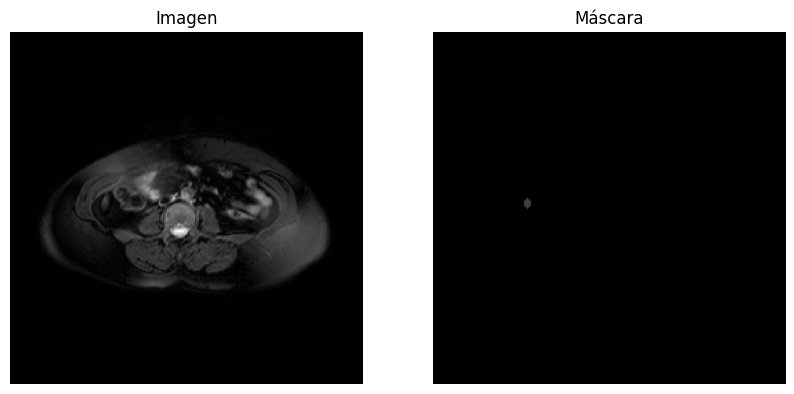

In [ ]:
# Select one patient
sample_path = f'{TRAIN_PATH}/{images_per_patient["images"].idxmin()}/T2SPIR/DICOM_anon'

# Select a random image
images_files = [f for f in os.listdir(sample_path) if os.path.isfile(os.path.join(sample_path, f))]
image_path = os.path.join(sample_path, np.random.choice(images_files).item())
mask_path = image_path.replace('DICOM_anon', 'Ground').replace('.dcm', '.png')

# Open both images
image = dicom.dcmread(image_path).pixel_array
mask = cv2.imread(mask_path)
print(f"Image shape: {image.shape}")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Image')
ax[0].axis('off')

ax[1].imshow(mask)
ax[1].set_title('Mask')
ax[1].axis('off')

plt.show()

The next step is to check the number of images per label. The criterion follows the dataset documentation:
- Liver: 63 (55-70)
- Right kidney: 126 (110-135)
- Left kidney: 189 (175-200)
- Spleen: 252 (240-255)

In [ ]:
# Value-to-label mapping
label_mapping = {
  63: 'Liver',
  126: 'Right Kidney',
  189: 'Left Kidney',
  252: 'Spleen'
}

# General report
report = {
  'Liver': 0,
  'Right Kidney': 0,
  'Left Kidney': 0,
  'Spleen': 0,
  'Without Label': 0,
  'patients': {}
}

# Iterate over the patient list
for patient in patients:
  masks_path = f'{TRAIN_PATH}/{patient}/T2SPIR/Ground'
  masks = [f for f in os.listdir(masks_path) if os.path.isfile(os.path.join(masks_path, f))]

  # Report by patient
  images_per_label = {
    'Liver': 0,
    'Right Kidney': 0,
    'Left Kidney': 0,
    'Spleen': 0,
    'Without Label': 0
  }

  # Iterate over each mask
  for mask in masks:
    mask_path = os.path.join(masks_path, mask)
    mask = cv2.imread(mask_path)

    # Unique values
    unique_pixels = np.unique(mask, axis=None)

    # Count
    for label_pixel in unique_pixels:
      no_label = True
      if label_pixel in label_mapping.keys():
        images_per_label[label_mapping[label_pixel]] += 1
        report[label_mapping[label_pixel]] += 1
        no_label = False

    if no_label:
      images_per_label['Without Label'] += 1
      report['Without Label'] += 1

  report['patients'][patient] = images_per_label

report_per_patient = report.pop('patients')
print(f'General report: {report}')
print('\nReport by patient:')
display(pd.DataFrame(report_per_patient).T)

General report: {'Liver': 408, 'Right Kidney': 251, 'Left Kidney': 264, 'Spleen': 242, 'Without Label': 131}

Report by patient:


,Liver,Right Kidney,Left Kidney,Spleen,Without Label
8,27,17,16,20,3
39,22,12,11,13,4
20,18,14,13,15,2
10,21,14,14,11,11
13,18,12,14,10,2
3,16,11,12,12,9
31,18,10,11,12,9
33,22,13,13,13,2
1,24,14,16,14,12
15,17,14,15,12,0


As expected, there are more images with liver labels. This is likely because the liver is significantly larger than the other organs. It is not possible to balance labels for the remaining organs independently, because increasing the number of images for one organ is very likely to increase the others as well when working with multi-label images.

### 1.3 Preprocessing

There are 623 images in total across 20 patients:
 - With liver: 408 (65.49%)
 - With right kidney: 251 (40.29%)
 - With left kidney: 264 (42.38%)
 - With spleen: 242 (38.84%)
 - Without label: 131 (21.03%)

#### Split
There are two options for splitting the images into train, validation, and test subsets:
1. Split the total set of images.
2. Split by patient.

The first option gives us a simpler data split and helps ensure the desired image percentage in each subset.

However, this strategy has a risk. If we split without considering patients, images from the same person may appear in every subset. If the model learns the anatomy of a specific person, validation and test accuracy can be artificially inflated.

We can avoid this with a patient-level split (the second option). We use 12 patients for training (60%), 4 for validation, and 4 for testing (20% each).

#### Transformations
The previous split leaves us with approximately 378 training images (12 patients x 31.5 images on average per patient). This is a small amount of data for training, so data augmentation can help mitigate the issue:
- Random horizontal flip: the organs are approximately symmetric.
- Random rotation (+/- 15 degrees): the anatomy is not heavily deformed.

Additionally, the values must be normalized. To do this, we need to identify the maximum value across all images, since the dataset does not specify it. Additional normalization may also be required depending on the model.

Masks also need preprocessing because they currently have shape `H x W`, with possible values `0, 63, 126, 189, 252`. These must be mapped to values from `0` to `4`.

Besides masks, we also need to prepare bounding boxes. These are generated from the masks.

#### DataFrame
We can prepare a DataFrame to randomly access all images in each subset without additional complexity.

#### Balance
Finally, the classes are not balanced. It is useful to compute each class weight so it can be considered during training.

In [ ]:
# SPLIT
VAL_SPLIT = 0.2
TEST_SPLIT = 0.2
print(f'Patient list: {patients}')
print(f'Patient list: {patients}')
train_patients = patients[:-int(len(patients) * (VAL_SPLIT + TEST_SPLIT))]
val_patients = patients[-int(len(patients) * (VAL_SPLIT + TEST_SPLIT)):-int(len(patients) * TEST_SPLIT)]
test_patients = patients[-int(len(patients) * TEST_SPLIT):]
print(f'Training patient list: {train_patients}')
print(f'Validation patient list: {val_patients}')
print(f'Test patient list: {test_patients}')
print(f'Test patient list: {test_patients}')

# MAX GLOBAL VALUE
MAX_GLOB = 0
for patient in patients:
  images_path = f'{TRAIN_PATH}/{patient}/T2SPIR/DICOM_anon'
  for f in os.listdir(images_path):
    image_path = os.path.join(images_path, f)

    if os.path.isfile(image_path):
      MAX_GLOB = max(MAX_GLOB, dicom.dcmread(image_path).pixel_array.max())

print(f'\nMáximo valor global: {MAX_GLOB}')

# DATAFRAME
images_to_df = []

# Iterate over the patient list
for patient in patients:
  # Define the dataset according to the split
  if patient in train_patients:
    dataset = 'train'
  elif patient in val_patients:
    dataset = 'val'
  elif patient in test_patients:
    dataset = 'test'

  # Check all files
  images_path = f'{TRAIN_PATH}/{patient}/T2SPIR/DICOM_anon'
  for f in os.listdir(images_path):
    image_path = os.path.join(images_path, f)

    if os.path.isfile(image_path):
      mask_path = image_path.replace('DICOM_anon', 'Ground').replace('.dcm', '.png')

      images_to_df.append({
        'patient': patient,
        'dataset': dataset,
        'image_path': image_path,
        'mask_path': mask_path
      })

df = pd.DataFrame(images_to_df)

print(f'\n\nNúmero de imágenes: {len(df)}')
print('División por subset:')
display(df.groupby('dataset').size().sort_values(ascending=False))
display(df.head())

# BALANCE
# Count pixels per class: [Background, Liver, Right Kidney, Left Kidney, Spleen]
labels = [0, 63, 126, 189, 252]
counts = np.zeros(len(labels))
for mask_path in df[df.dataset == 'train']['mask_path'].values:
  mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
  for i, label in enumerate(labels):
    counts[i] += (mask == label).sum()
weights = counts.sum() / counts
CLASS_WEIGHTS = (weights / weights.sum())
print(f'\nClass balance: {CLASS_WEIGHTS}')

Patient list: ['8', '39', '20', '10', '13', '3', '31', '33', '1', '15', '5', '34', '22', '36', '32', '38', '2', '19', '37', '21']
Training patient list: ['8', '39', '20', '10', '13', '3', '31', '33', '1', '15', '5', '34']
Patient list de validación: ['22', '36', '32', '38']
Test patient list: ['2', '19', '37', '21']

Máximo valor global: 2648


Número de imágenes: 623
División por subset:


,0
dataset,
train,360
val,144
test,119


,patient,dataset,image_path,mask_path
0,8,train,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...
1,8,train,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...
2,8,train,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...
3,8,train,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...
4,8,train,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...,/content/dataset/CHAOS_Train_Sets/Train_Sets/M...



Class balance: [  0.0015802    0.045571     0.36977     0.36483     0.21825]


## 2. Data Module

In [ ]:
class CHAOSDataset(Dataset):
  def __init__(self, df: pd.DataFrame, transform: v2.Compose = None, max_glob: int = MAX_GLOB):
    super().__init__()
    self.df = df
    self.transform = transform
    self.max_glob = max_glob
    self.label_mapping = {
      63: 1, # Liver
      126: 2, # Right kidney
      189: 3, # Left kidney
      252: 4  # Spleen
    }

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    # Image normalizada de 0 a 1
    image = Image(dicom.dcmread(row['image_path']).pixel_array / self.max_glob)
    image = v2.ToDtype(torch.float32)(image)

    # Get boxes, masks, and labels
    target = self._get_instance_info(row['mask_path'])

    if self.transform:
      image, target = self.transform(image, target)

    return image, target

  def _get_instance_info(self, mask_path: str) -> dict:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    h, w = mask.shape

    labels = []
    instance_masks = []

    # Get organs present in the image
    unique_labels = np.unique(mask[mask != 0])

    # Iterate over each organ
    for label_val in unique_labels:
      # Create the binary mask
      binary_mask = (mask == label_val).astype(np.uint8)
      labels.append(self.label_mapping[label_val])
      instance_masks.append(binary_mask)

    if len(labels) == 0:
      labels = np.zeros((0,))
      instance_masks = np.zeros((0, h, w))
    else:
      labels = np.array(labels)
      instance_masks = np.array(instance_masks)

    masks = Mask(torch.tensor(instance_masks, dtype=torch.uint8))
    boxes = BoundingBoxes(masks_to_boxes(masks), dtype=torch.float32, format="XYXY", canvas_size=(h, w))
    labels = torch.tensor(labels, dtype=torch.int64)

    return {
      "boxes": boxes,
      "labels": labels,
      "masks": masks
    }

class CHAOSDataModule(LightningDataModule):
  def __init__(self, df: pd.DataFrame, batch_size: int = 16, norm_mean: list = [0], norm_std: list = [1]):
    super().__init__()
    self.df = df
    self.batch_size = batch_size
    self.norm_mean = norm_mean
    self.norm_std = norm_std

  def setup(self, stage: str = None):
    if stage == 'fit' or stage is None:
      self.train_dataset = CHAOSDataset(self.df[self.df['dataset'] == 'train'], self._build_transform('train'))
      self.val_dataset = CHAOSDataset(self.df[self.df['dataset'] == 'val'], self._build_transform('val'))

    elif stage == 'test':
      self.test_dataset = CHAOSDataset(self.df[self.df['dataset'] == 'test'], self._build_transform('test'))

  def _build_transform(self, dataset: str) -> v2.Compose:
    transforms_list = [
      v2.Resize(256),
      v2.Normalize(mean=self.norm_mean, std=self.norm_std)
    ]

    if dataset == 'train':
      transforms_list.extend([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=15)
      ])

    return v2.Compose(transforms_list)

  def collate_fn(self, batch):
    images, targets = zip(*batch)

    images = torch.stack(images)

    return images, targets

  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True, collate_fn=self.collate_fn)

  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=self.collate_fn)

  def test_dataloader(self):
    return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=self.collate_fn)

Number of samples per split:
	Training: 360
	Validation: 144
	Test: 119

Sample
Image shape: torch.Size([1, 256, 256]) (torch.float32)
Mask shape: torch.Size([4, 256, 256]) (torch.uint8)
Bounding-box shape: torch.Size([4, 4]) (torch.float32)
Label shape: torch.Size([4]) (torch.int64)


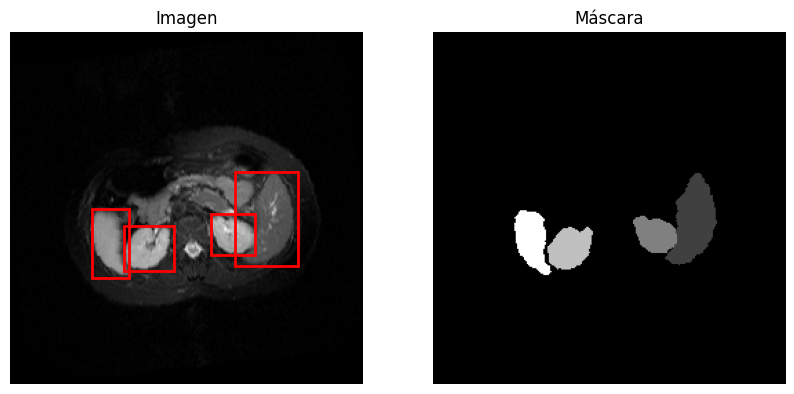

In [ ]:
data_module = CHAOSDataModule(df)
data_module.setup('fit')
train_dataset = data_module.train_dataset
val_dataset = data_module.val_dataset

data_module.setup('test')
test_dataset = data_module.test_dataset

print('Number of samples per split:')
print(f'	Training: {len(train_dataset)}')
print(f'	Validation: {len(val_dataset)}')
print(f'	Test: {len(test_dataset)}')

print('\nSample')
images, targets = next(iter(data_module.train_dataloader()))
image, target = images[0], targets[0]
print(f"Image shape: {image.shape} ({image.dtype})")
print(f"Mask shape: {target['masks'].shape} ({target['masks'].dtype})")
print(f"Bounding-box shape: {target['boxes'].shape} ({target['boxes'].dtype})")
print(f"Label shape: {target['labels'].shape} ({target['labels'].dtype})")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Image
ax[0].imshow(image.squeeze(), cmap='gray')
ax[0].set_title('Image')
ax[0].axis('off')

# Mask
mask = np.zeros(image.shape)
if len(target['masks']) > 0:
  masks = np.array([i * mask for i, mask in enumerate(target['masks'], start=1)])
  mask = masks.sum(axis=0, keepdims=True)
ax[1].imshow(mask.squeeze(), cmap='gray')
ax[1].set_title('Mask')
ax[1].axis('off')

# Bounding boxes
if len(target['boxes']) > 0:
  for box in target['boxes']:
    rect = plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                         fill=False, edgecolor='red', linewidth=2)
    ax[0].add_patch(rect)

plt.show()


## 3. Baseline

For the baseline, we use YOLO in a zero-shot setup. In other words, we do not fine-tune it in any way on our training data; we only inspect its predictions.

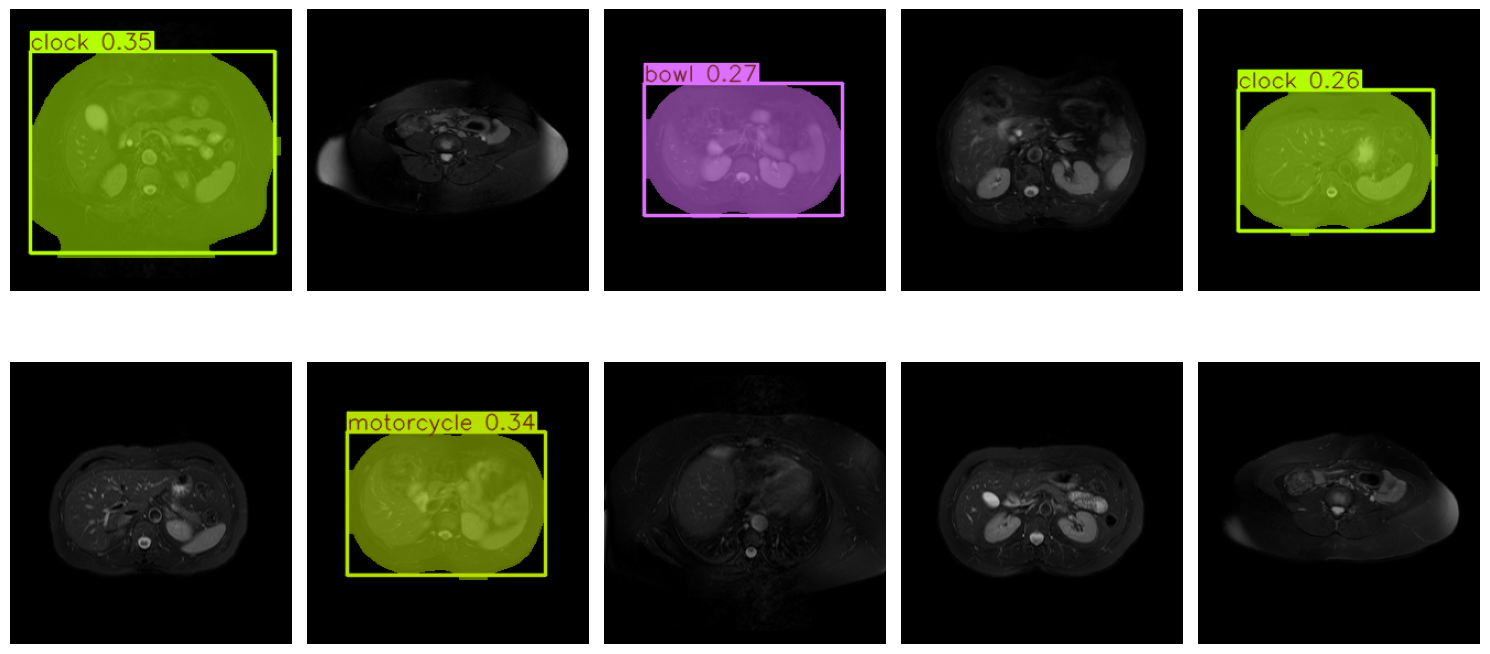

In [ ]:
# Load the model
model = YOLO("yolo26n-seg.pt")

# Prepare the data
data_module = CHAOSDataModule(df, batch_size=4)
data_module.setup('test')
test_dataset = data_module.test_dataset

# Choose random samples
samples = np.random.choice(len(test_dataset), 10)
images = [test_dataset[i][0] for i in samples]
images = torch.stack(images)

# Predict
images = images.expand(-1, 3, -1, -1) # YOLO expects 3-channel images, so expand the channel dimension
results = model.predict(images, verbose=False)

# Plot predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()
for i, result in enumerate(results):
  axes[i].imshow(result.plot())
  axes[i].axis('off')

plt.tight_layout()
plt.show()

As expected, the model either detects nothing in the images or predicts objects that do not make sense.

Unlike typical baselines, it is not meaningful to compute metrics for this one because the model is not adapted to our target classes. The model simply shows that it is **necessary** to fine-tune this type of architecture for this task. No matter how strong the pretraining is, a generic model will not handle this type of medical image directly.

YOLO could be fine-tuned on this dataset, but that would require redefining the dataset format. We do not consider it necessary for the results we are looking for. More details are available in the [Ultralytics documentation](https://docs.ultralytics.com/tasks/segment/#train).

## 4. Proposed Models

It is important to distinguish between two types of segmentation models:
- **Semantic segmentation:** assumes there is at most one object per class in the same image. For a single image, the output has shape `(Classes, H, W)`, assigning each pixel a probability of belonging to each class. This is how UNet works.
- **Instance segmentation:** models can detect and segment multiple objects of the same class in a single image. Mask R-CNN is an example of this approach. Unlike UNet, Mask R-CNN returns a dictionary containing lists of:
    - `Scores`: probability associated with the predicted class.
    - `Labels`: assigned label or class.
    - `Masks`: instance segmentation mask with values from 0 to 1.
    - `Boxes`: bounding box enclosing the instance.

   The length of the lists depends on how many instances were found in the image.

To make a fair comparison between both models, we use the `Dice coefficient` across the 4 organ classes, excluding background. To do this, both semantic and instance segmentation outputs must be transformed into a simple `(H, W)` mask whose values correspond to the labels. Then we can compare the complete ground-truth mask with the model output.

For UNet, we can apply `argmax` over the class dimension. For instance models, we reconstruct the mask using thresholds over both the score and mask values to create an `(H, W)` mask, as done earlier when plotting masks in the DataModule section.
For more details on this calculation, see the `ModuleEvaluator` class.

### 4.1 UNet

As a first proposal, we use a U-Net architecture. It is simple but effective for segmentation.

Because this is a segmentation problem, we use two objectives: Pixel Accuracy through CrossEntropy, plus Dice Loss.

In [ ]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.1):
    super().__init__()

    self.block = nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.LeakyReLU(inplace=True),
      nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.LeakyReLU(inplace=True),
      nn.Dropout2d(dropout)
    )

  def forward(self, x):
    return self.block(x)

class UNet(nn.Module):
  def __init__(self, in_channels: int = 1, num_classes: int = 5, num_layers: int = 4):
    super().__init__()

    # Encoder
    self.encoder = nn.ModuleList()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    for i in range(num_layers):
      if i == 0:
        self.encoder.append(ConvBlock(in_channels, 64))
      else:
        self.encoder.append(ConvBlock(64 * 2 ** (i - 1), 64 * 2 ** i))
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Bottleneck
    self.bottleneck = ConvBlock(64 * 2 ** (num_layers - 1), 64 * 2 ** num_layers)

    # Decoder
    self.decoder = nn.ModuleList()
    self.upconv = nn.ModuleList()
    for i in range(num_layers):
      self.upconv.append(nn.ConvTranspose2d(64 * 2 ** (num_layers - i), 64 * 2 ** (num_layers - i - 1), kernel_size=2, stride=2))
      self.decoder.append(ConvBlock(64 * 2 ** (num_layers - i), 64 * 2 ** (num_layers - i - 1)))

    # Head
    self.head = nn.Conv2d(64, num_classes, kernel_size=1)

  def forward(self, x):
    # Encoder
    skip_connections = []
    for encoder in self.encoder:
      x = encoder(x)
      skip_connections.append(x)
      x = self.pool(x)

    # Bottleneck
    x = self.bottleneck(x)

    # Decoder
    skip_connections = skip_connections[::-1]
    for i in range(len(self.decoder)):
      x = self.upconv[i](x)
      x = torch.cat((skip_connections[i], x), dim=1)
      x = self.decoder[i](x)

    # Head
    return self.head(x)

class SegmentationUNetModule(LightningModule):
  def __init__(self, class_weights: list = None, dice_weight: float = 1., optimizer_params: dict = { 'lr': 1e-3 }, batch_size: int = 16):
    super().__init__()
    self.save_hyperparameters()

    self.model = UNet()
    self.dice_weight = dice_weight
    self.optimizer_params = optimizer_params
    self.batch_size = batch_size
    if class_weights is not None:
      self.register_buffer('class_weights', torch.tensor(class_weights, dtype=torch.float32))
    else:
      self.class_weights = None

  def forward(self, x):
    return self.model(x)

  def training_step(self, batch, _batch_idx):
    return self._compute_batch(batch, 'train')

  def validation_step(self, batch, _batch_idx):
    return self._compute_batch(batch, 'val')

  def test_step(self, batch, _batch_idx):
    return self._compute_batch(batch, 'test')

  def configure_optimizers(self):
    return AdamW(self.parameters(), **self.optimizer_params)

  def configure_callbacks(self):
    return [PlotCallback()]

  def _compute_batch(self, batch, stage: str):
    images, targets = batch # images (B, 1, H, W), targets: (B, {'boxes': BB, 'labels': tensor, 'masks': Mask})

    batch_size, _, H, W = images.shape

    # Prepare masks to include background
    # This is necessary because target['masks'] has shape (Detected Instances, H, W)
    # Detected Instances can range from 0 to 4: 0 when there is nothing in the image, 4 when all organs are present
    # Semantic Mask Shape: (B, H, W)
    semantic_masks = torch.zeros(batch_size, H, W, dtype=torch.long, device=self.device)
    for i in range(batch_size):
      for j, (label, mask) in enumerate(zip(targets[i]['labels'], targets[i]['masks'])):
        semantic_masks[i][mask == 1] = label

    logits = self(images) # (B, Classes, H, W)
    loss, ce_loss, dice_loss = self._compute_loss(logits, semantic_masks)

    self.log_dict({
      f'{stage}_loss': loss,
      f'{stage}_cross_entropy_loss': ce_loss,
      f'{stage}_dice_loss': dice_loss
    }, prog_bar=True, on_epoch=True, on_step=False, batch_size=self.batch_size)

    return loss

  def _compute_loss(self, logits, masks):
    # Compute pixel accuracy with CrossEntropyLoss
    ce_loss = F.cross_entropy(logits, masks, weight=self.class_weights)

    # Compute Dice Loss
    probs = logits.softmax(dim=1) # (B, Classes, H, W)
    one_hot_mask = F.one_hot(masks, num_classes=probs.shape[1]).permute(0, 3, 1, 2) # (B, Classes, H, W)

    dims = (0, 2, 3)
    intersection = (probs * one_hot_mask).sum(dims)
    union  = (probs + one_hot_mask).sum(dims)
    dice_per_ch  = (2 * (intersection + 1e-6)) / (union + 1e-6) # (Classes,)
    dice_loss_per_ch  = 1 - dice_per_ch
    dice_loss = dice_loss_per_ch.mean()

    # Compute total loss
    loss = ce_loss + self.dice_weight * dice_loss

    return loss, ce_loss, dice_loss

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/results exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ UNet │ 31.0 M │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 31.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 31.0 M                                                                                               
Total estimated model params size (MB): 124                                                                        
Modules in train mode: 91                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(24) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

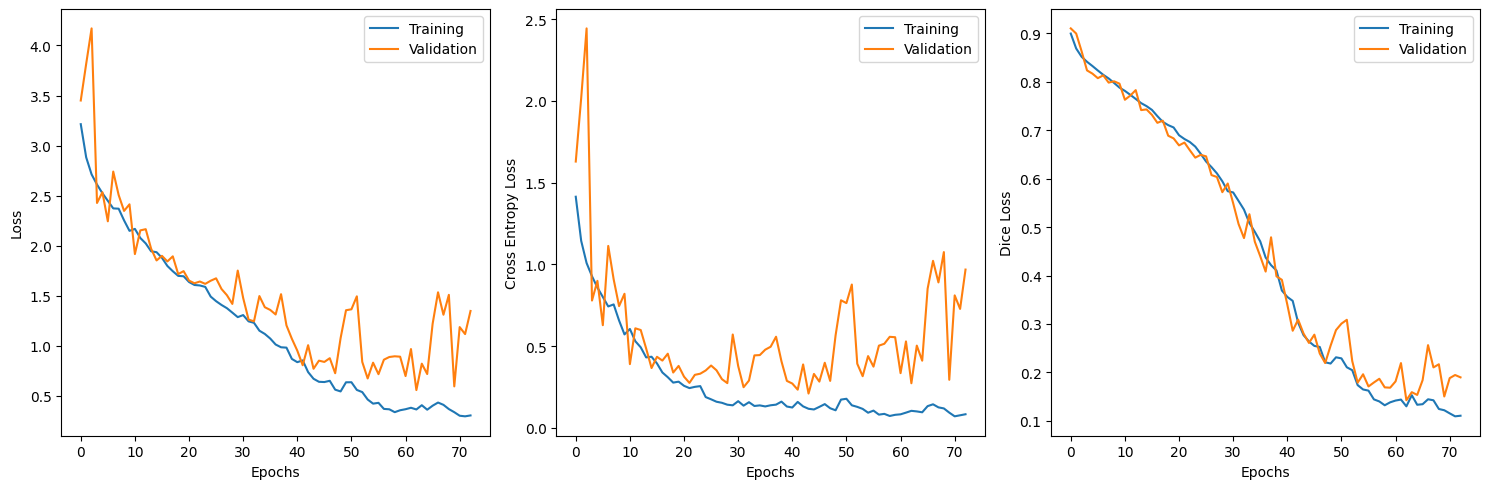

In [ ]:
optimizer_params = { 'lr': 1e-4 }
batch_size = 16
data_module = CHAOSDataModule(df, batch_size=batch_size)

module = SegmentationUNetModule(class_weights=CLASS_WEIGHTS, optimizer_params=optimizer_params, dice_weight=2, batch_size=batch_size)

trainer = Trainer(
  max_epochs=100,
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=10),
      ModelCheckpoint(monitor='val_loss', filename='unet', dirpath=f'{BASE_PATH}/results', enable_version_counter=False)
  ]
)
trainer.fit(module, data_module)

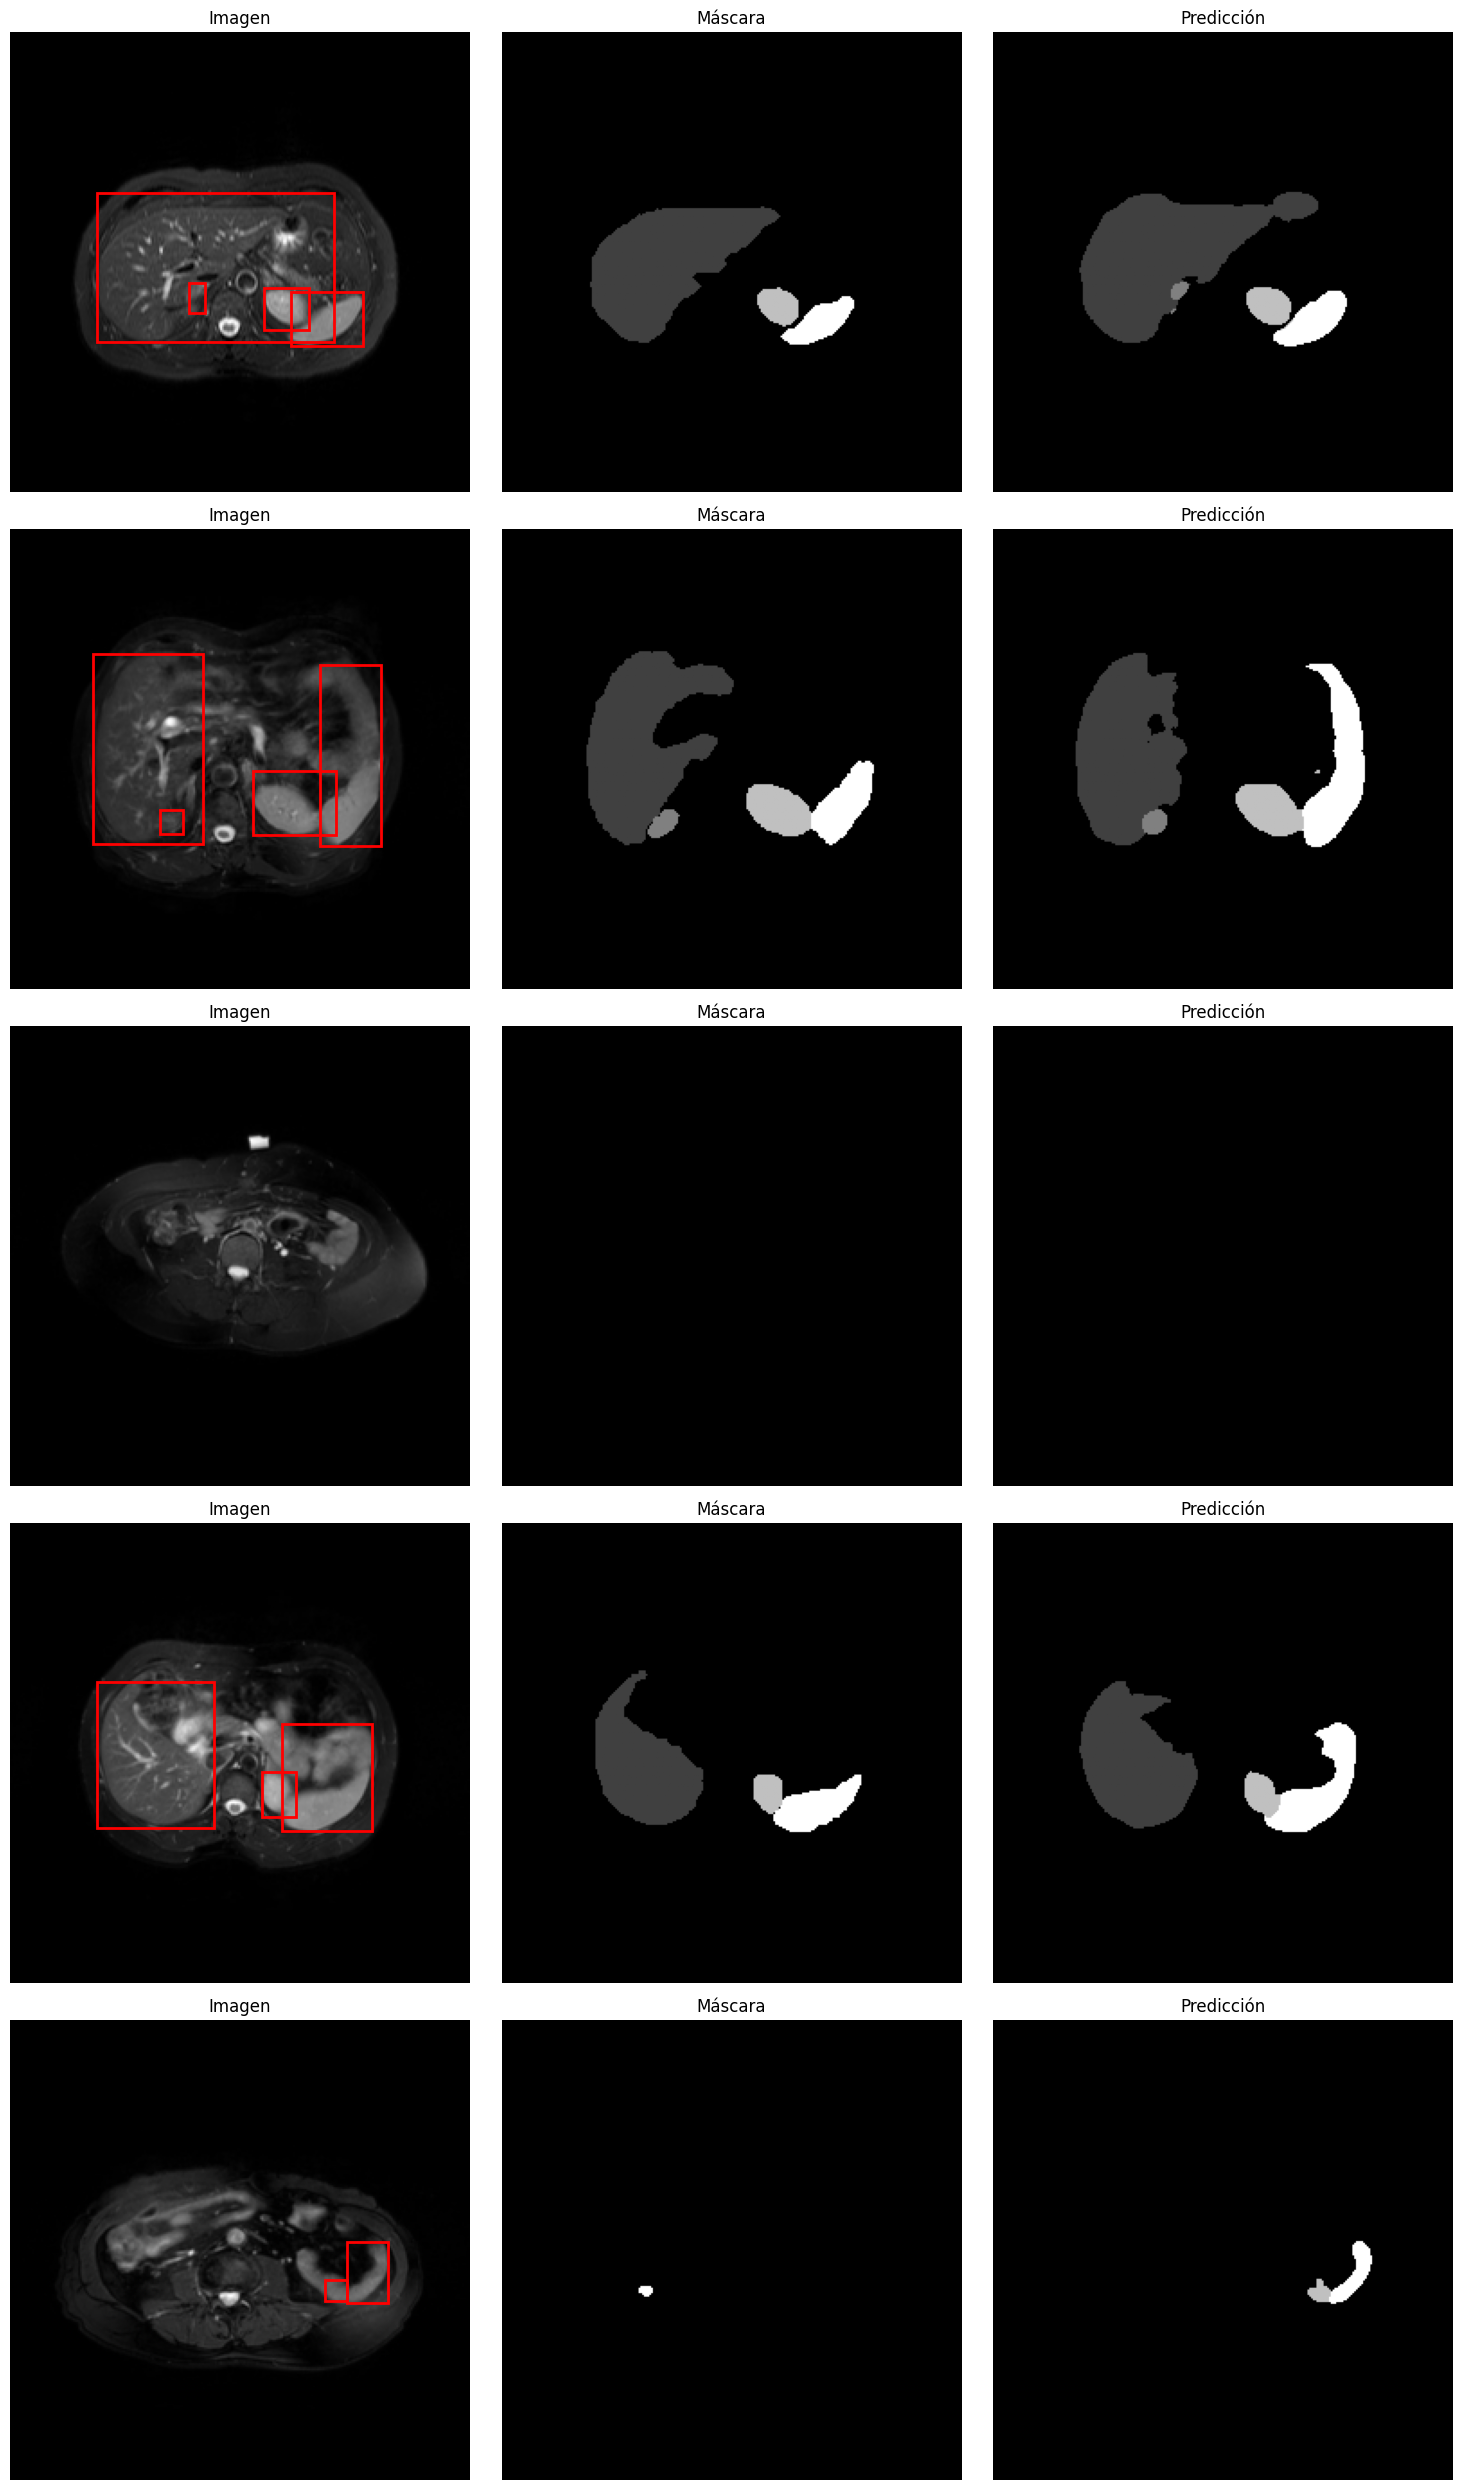

{'Dice Coef Liver': 0.8791238069534302,
 'Dice Coef Right Kidney': 0.8971647024154663,
 'Dice Coef Left Kidney': 0.8715367913246155,
 'Dice Coef Spleen': 0.6839514970779419,
 'Mean Dice Coef': 0.8329442143440247}

In [ ]:
module = SegmentationUNetModule.load_from_checkpoint(f'{BASE_PATH}/results/unet.ckpt', weights_only=False)
evaluator = ModuleEvaluator(model=module, model_type='semantic')

data_module.setup('test')
evaluator.plot_predictions(dataset=data_module.test_dataset)
evaluator.evaluate(dataloader=data_module.test_dataloader())

### 4.2 Mask R-CNN

TorchVision already provides a Mask R-CNN model, with or without pretrained weights. The model returns different outputs depending on whether it is in training or inference mode.

During training, it returns a dictionary with all losses: mask, classification, boxes, and others. As a first approach, all losses are weighted equally. It is important to set the validation step to training mode so validation losses are returned instead of inference outputs.

During inference, it returns a list of dictionaries containing masks, boxes, labels, and scores for all detected instances. In this case, we define a threshold to filter out instances that are not useful and reconstruct the masks.

In [ ]:
class MaskRCNNModule(LightningModule):
  def __init__(self, num_classes: int = 5, pretrained: bool = False, optimizer_params: dict = { 'lr': 1e-3 }, batch_size: int = 16):
    super().__init__()
    self.save_hyperparameters()

    if pretrained:
      # Load model with default weights
      self.model = maskrcnn_resnet50_fpn_v2(weights='DEFAULT', weights_backbone='DEFAULT', trainable_backbone_layers=1)

      # Modify bounding-box prediction head
      in_features = self.model.roi_heads.box_predictor.cls_score.in_features
      self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

      # Modify mask prediction head
      in_features_mask = self.model.roi_heads.mask_predictor.conv5_mask.in_channels
      self.model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    else:
      self.model = maskrcnn_resnet50_fpn_v2(num_classes=num_classes)

    self.optimizer_params = optimizer_params
    self.batch_size = batch_size

  def forward(self, images, targets=None):
    if targets is not None:
      return self.model(images, targets)
    else:
      return self.model(images)

  def training_step(self, batch, _batch_idx):
    return self._compute_batch(batch, 'train')

  def validation_step(self, batch, _batch_idx):
    self.train()
    with torch.no_grad():
      return self._compute_batch(batch, 'val')

  def test_step(self, batch, _batch_idx):
    self.train()
    with torch.no_grad():
      return self._compute_batch(batch, 'test')

  def configure_optimizers(self):
    return AdamW(self.parameters(), **self.optimizer_params)

  def configure_callbacks(self):
    return [PlotCallback()]

  def _compute_batch(self, batch, stage: str):
    images, targets = batch
    loss_dict =  self(images, targets)

    loss = sum(loss for loss in loss_dict.values())
    loss_dict = { f'{stage}_{k}': v for k, v in loss_dict.items() }
    loss_dict[f'{stage}_loss'] = loss

    self.log_dict(loss_dict, prog_bar=True, on_epoch=True, on_step=False, batch_size=self.batch_size)

    return loss

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/UPM/results exists and is not empty.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/UPM/results/mask-rcnn.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MaskRCNN │ 45.9 M │ train │     0 │
└───┴───────┴──────────┴────────┴───────┴───────┘

Trainable params: 45.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 45.9 M                                                                                               
Total estimated model params size (MB): 183                                                                        
Modules in train mode: 239                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/drive/MyDrive/UPM/results/mask-rcnn.ckpt


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

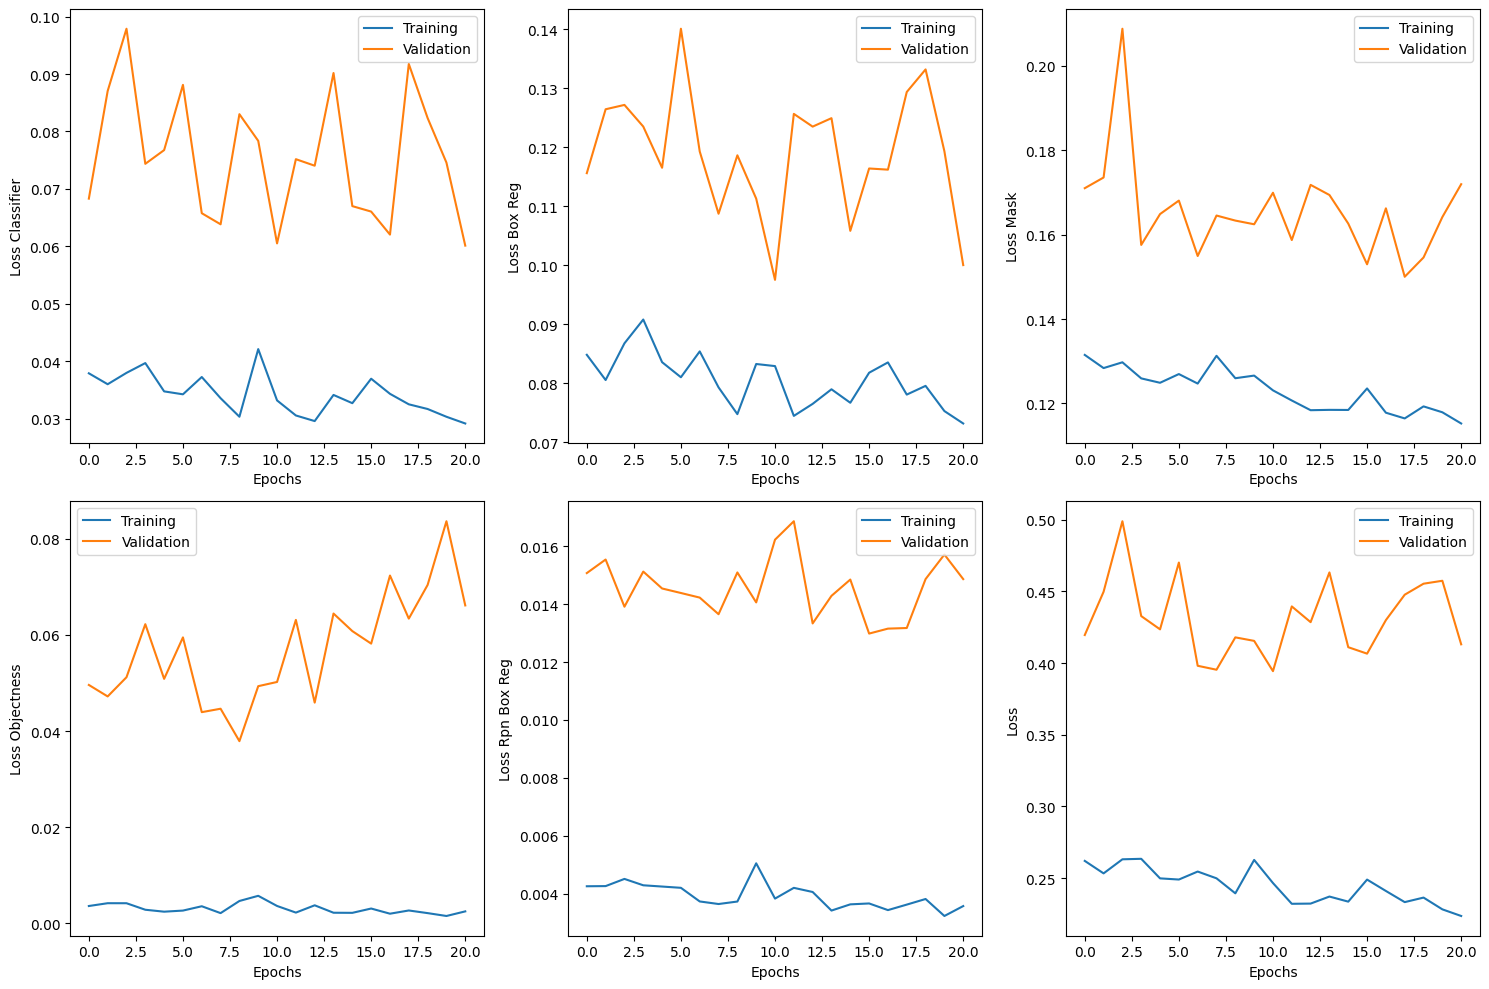

In [ ]:
batch_size = 4
data_module = CHAOSDataModule(df, batch_size=batch_size)
optimizer_params = { 'lr': 1e-4 }

gc.collect()
torch.cuda.empty_cache()

module = MaskRCNNModule(optimizer_params=optimizer_params, batch_size=batch_size)

trainer = Trainer(
  max_epochs=100,
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=10),
      ModelCheckpoint(monitor='val_loss', filename='mask-rcnn', dirpath=f'{BASE_PATH}/results', enable_version_counter=False)
  ]
)
trainer.fit(module, data_module, ckpt_path=f'{BASE_PATH}/results/mask-rcnn.ckpt', weights_only=False)

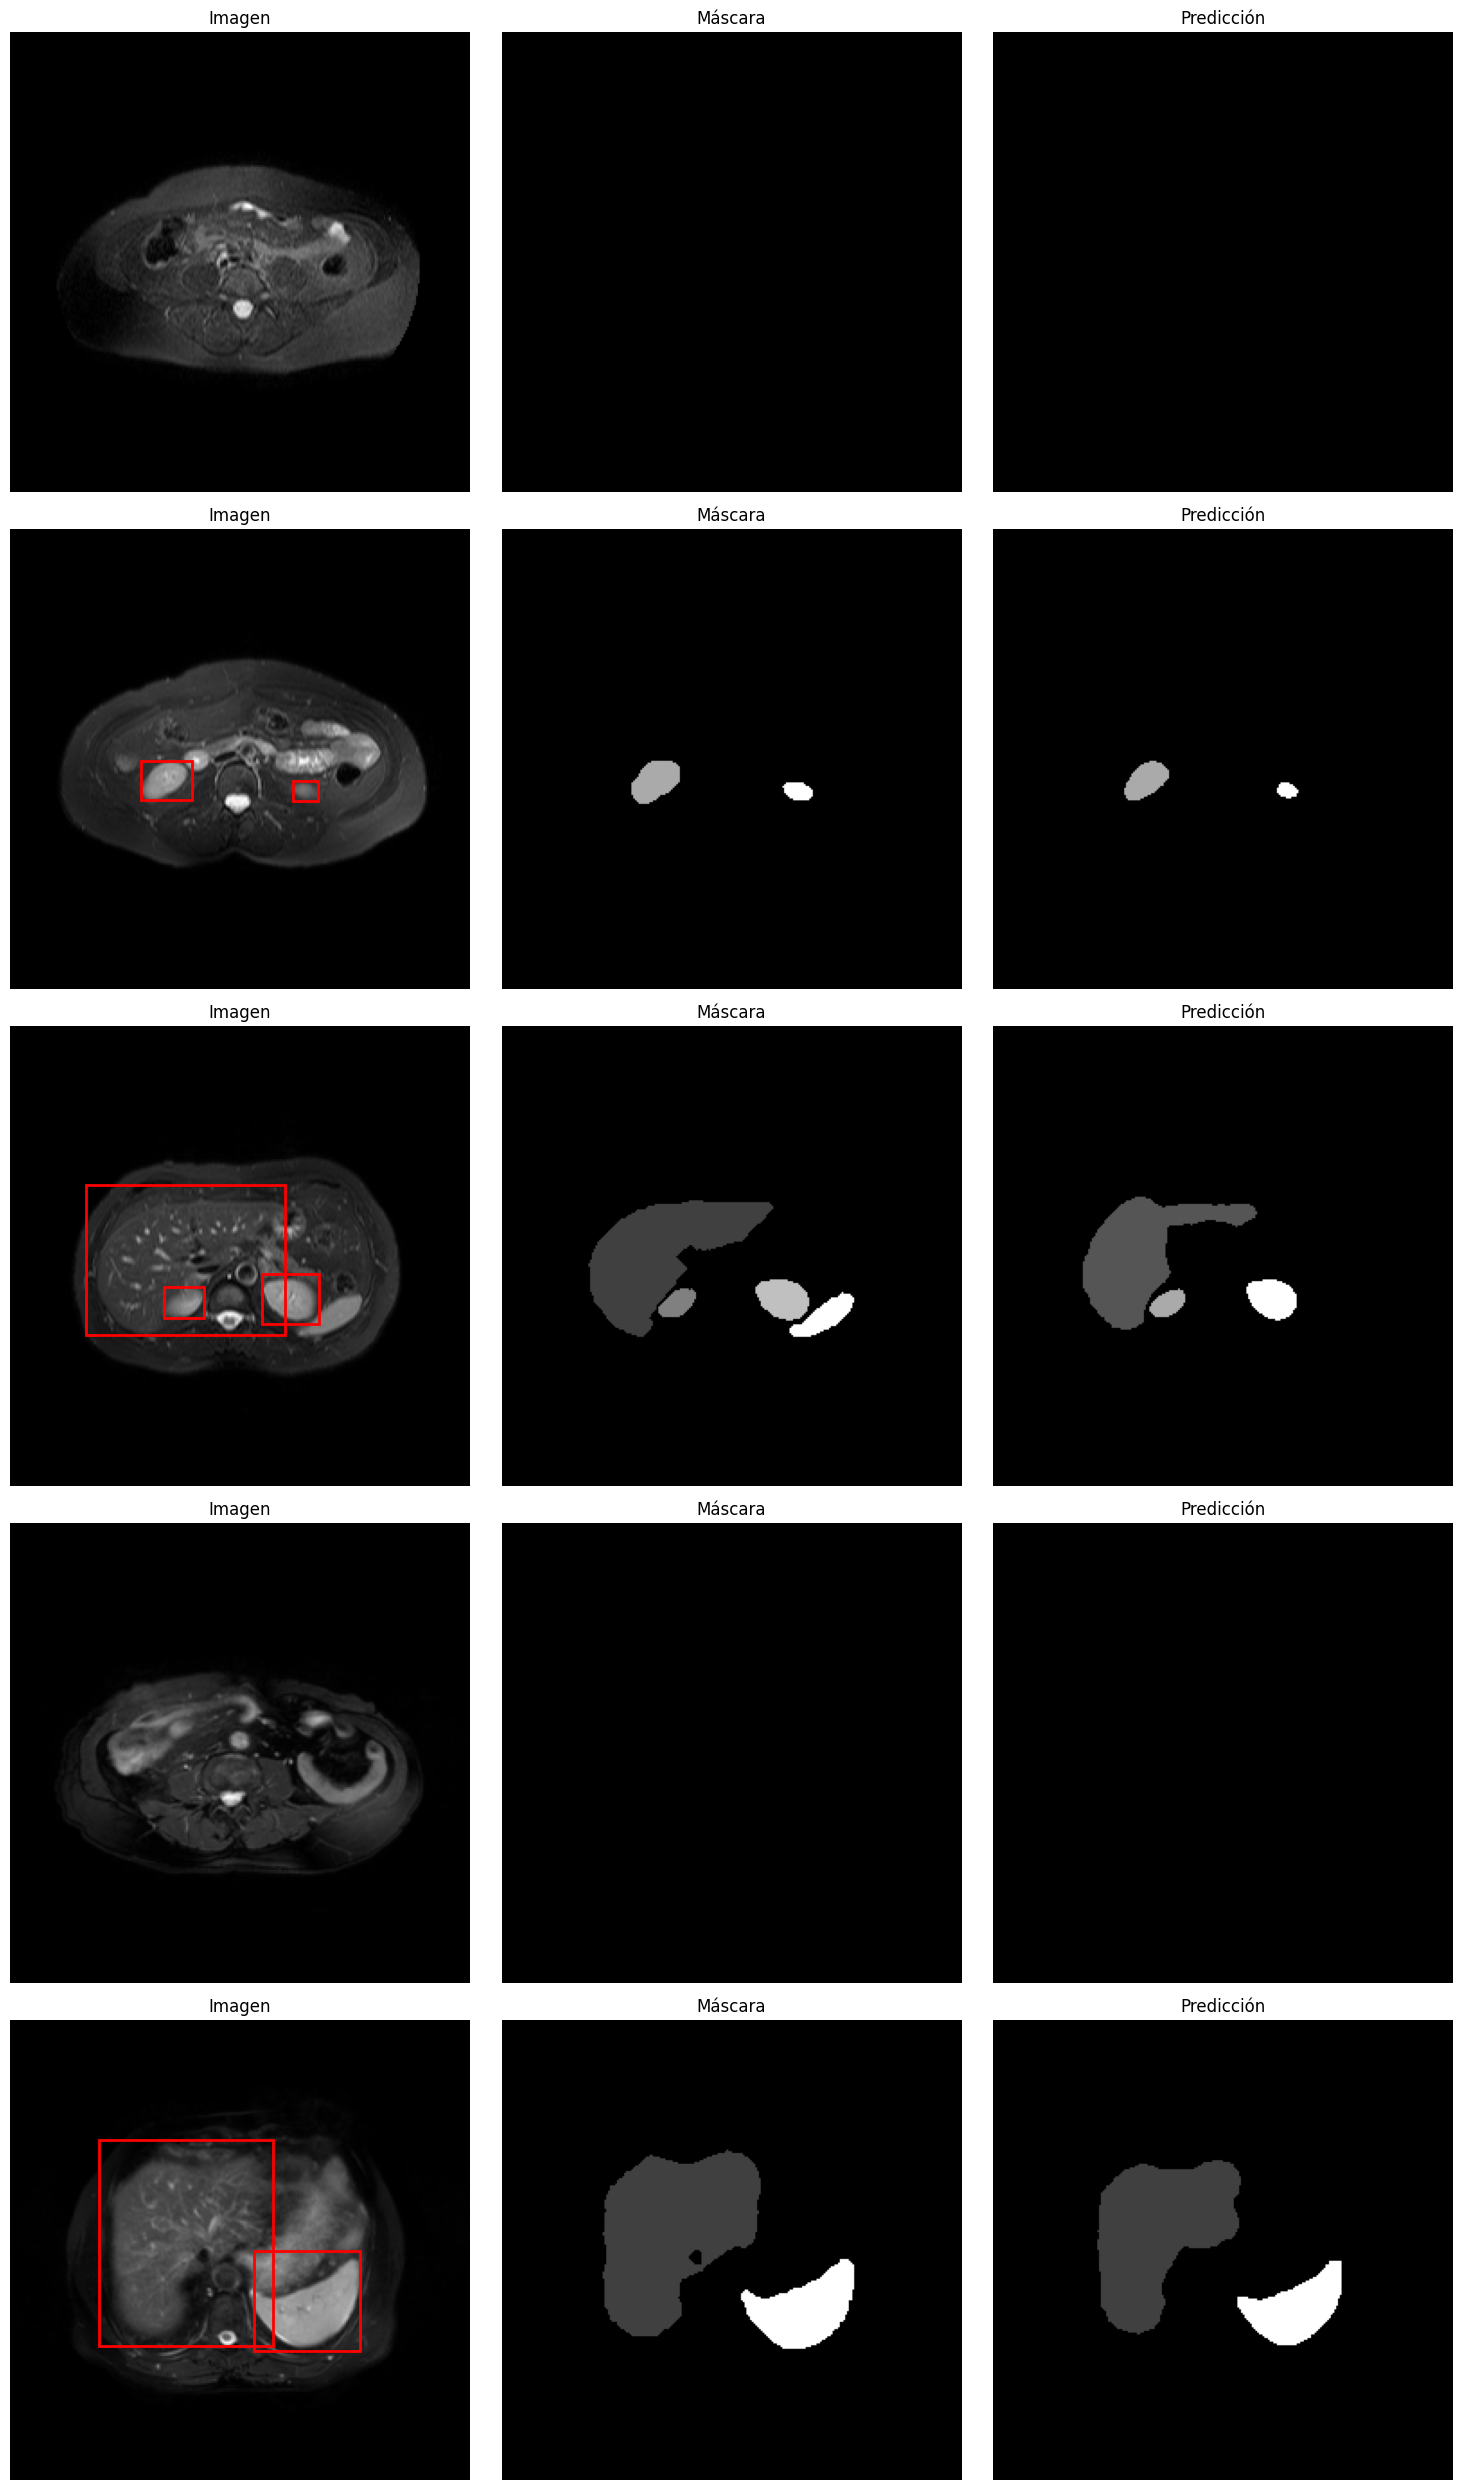

{'Dice Coef Liver': 0.8445764780044556,
 'Dice Coef Right Kidney': 0.8392883539199829,
 'Dice Coef Left Kidney': 0.7614938020706177,
 'Dice Coef Spleen': 0.7012009620666504,
 'Mean Dice Coef': 0.786639928817749}

In [ ]:
module = MaskRCNNModule.load_from_checkpoint(f'{BASE_PATH}/results/mask-rcnn.ckpt', weights_only=False)
evaluator = ModuleEvaluator(model=module, model_type='instance')

data_module.setup('test')
instance_threshold = 0.8
evaluator.plot_predictions(dataset=data_module.test_dataset, instance_threshold=instance_threshold)
evaluator.evaluate(dataloader=data_module.test_dataloader(), instance_threshold=instance_threshold)

Let's compare the results when using a pretrained Mask R-CNN model.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MaskRCNN │ 45.9 M │ train │     0 │
└───┴───────┴──────────┴────────┴───────┴───────┘

Trainable params: 37.4 M                                                                                           
Non-trainable params: 8.5 M                                                                                        
Total params: 45.9 M                                                                                               
Total estimated model params size (MB): 183                                                                        
Modules in train mode: 239                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

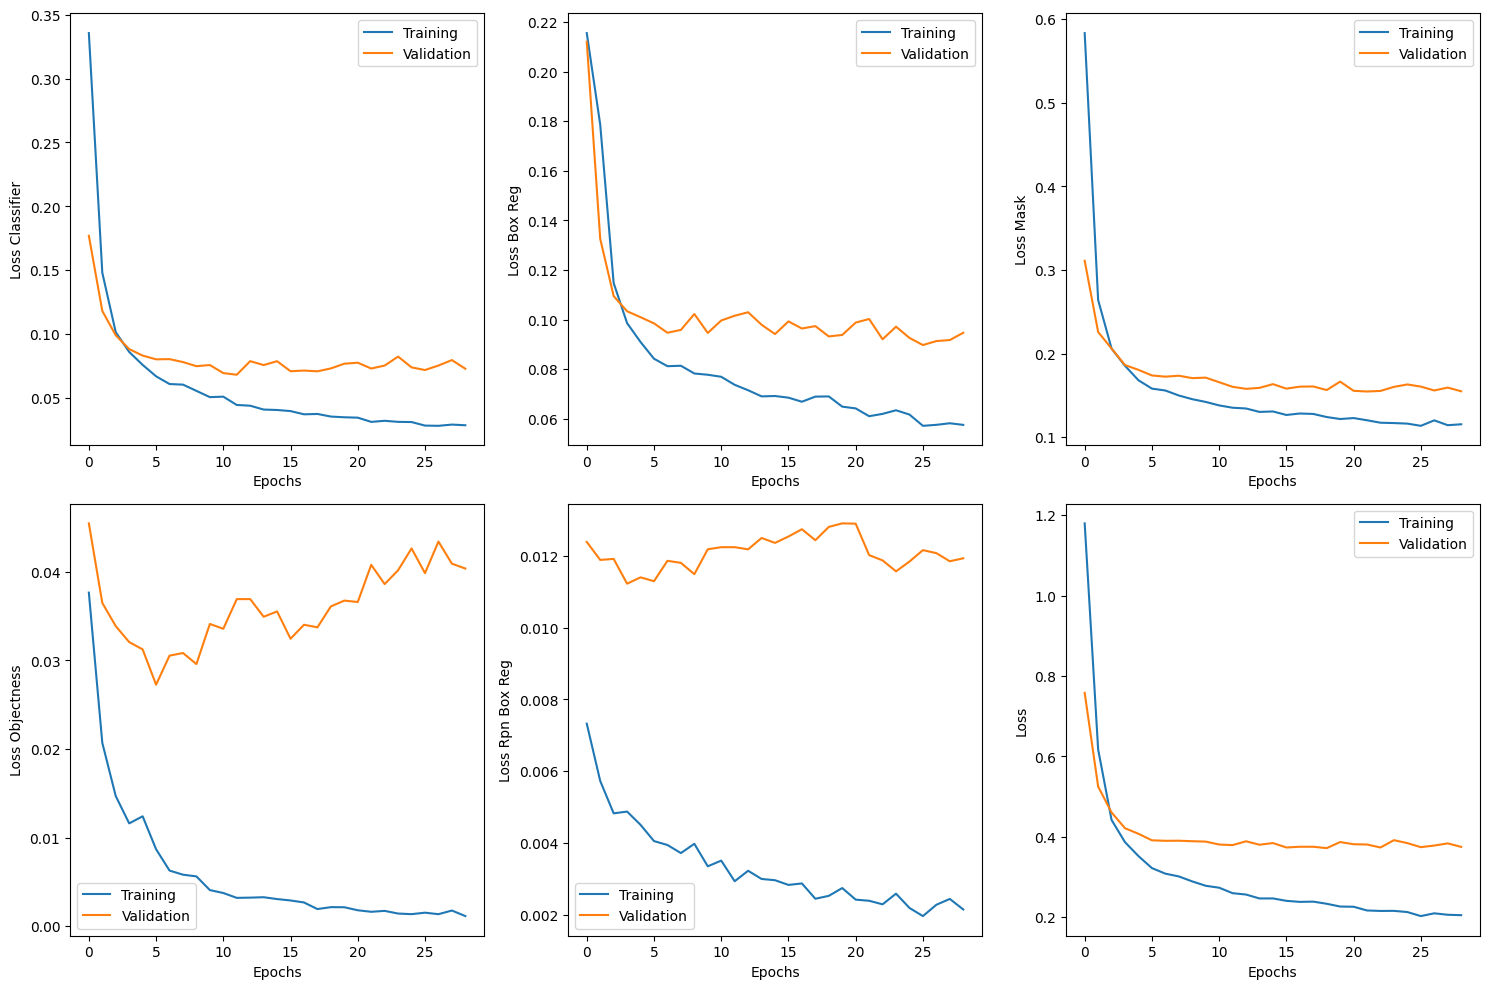

In [ ]:
batch_size = 4
data_module = CHAOSDataModule(df, batch_size=batch_size)
optimizer_params = { 'lr': 1e-5 }

gc.collect()
torch.cuda.empty_cache()

module = MaskRCNNModule(optimizer_params=optimizer_params, pretrained=True, batch_size=batch_size)

trainer = Trainer(
  max_epochs=100,
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=10),
      ModelCheckpoint(monitor='val_loss', filename='pretrained-mask-rcnn', dirpath=f'{BASE_PATH}/results', enable_version_counter=False)
  ]
)
trainer.fit(module, data_module)

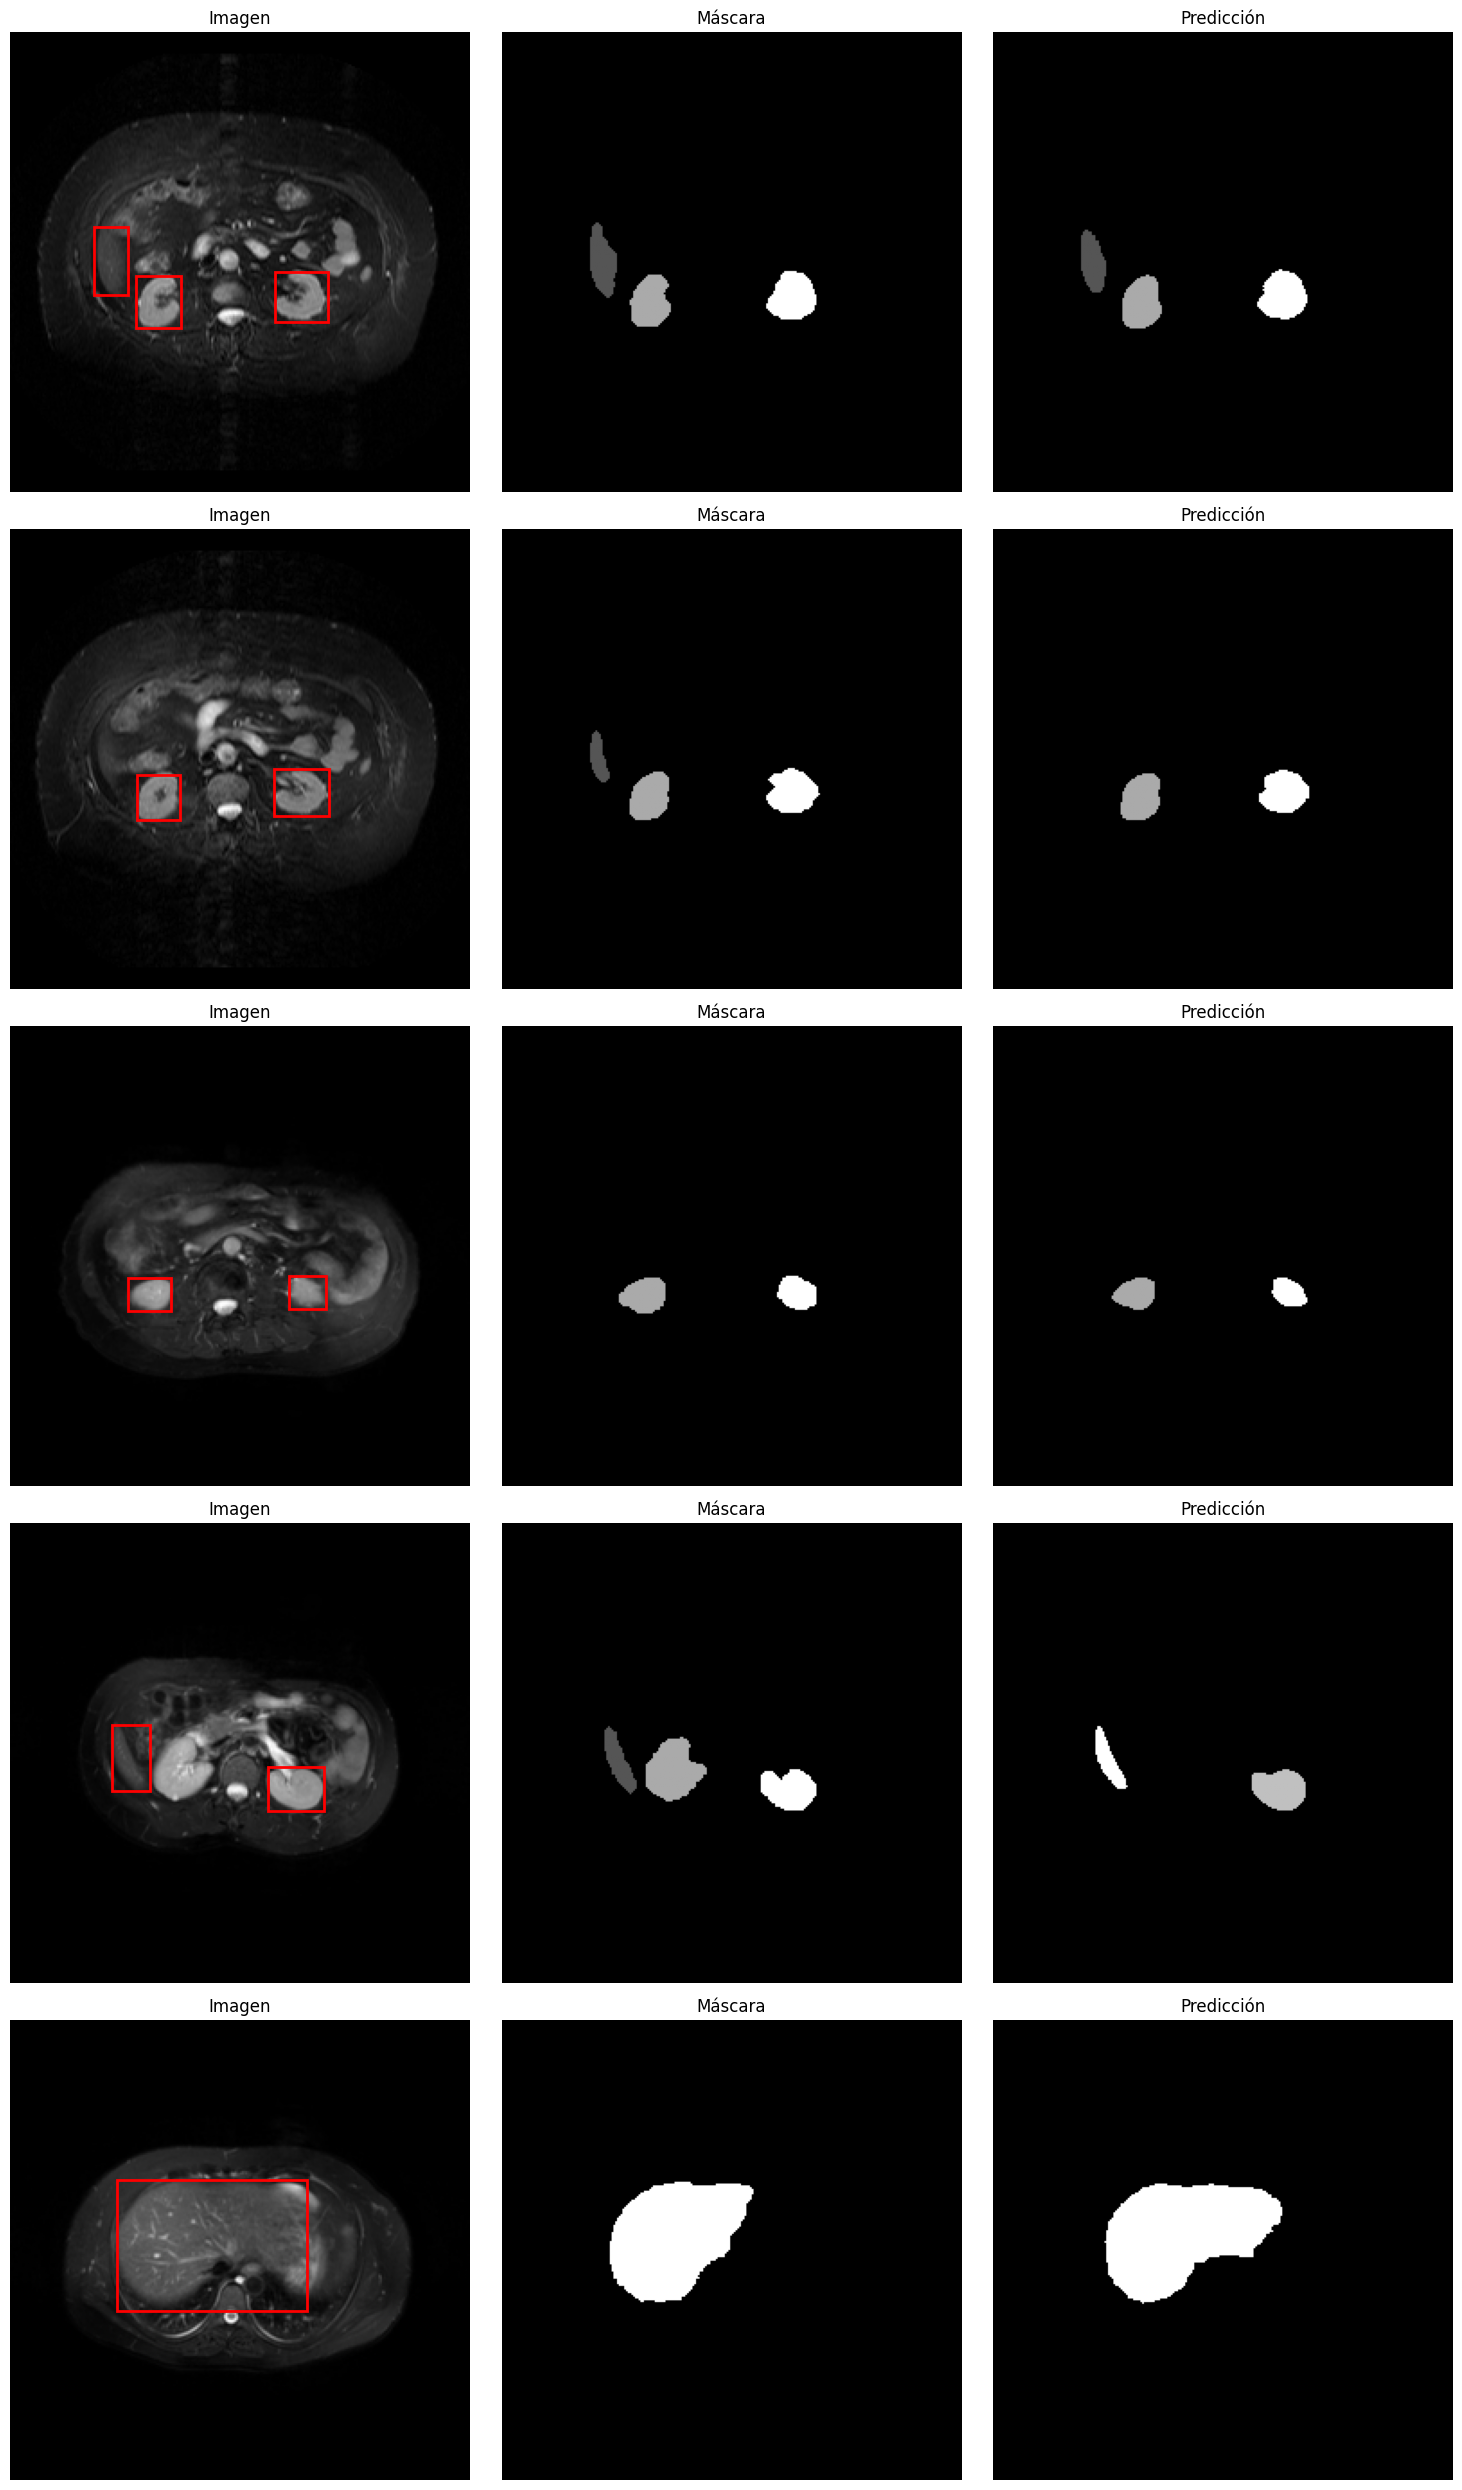

{'Dice Coef Liver': 0.8490575551986694,
 'Dice Coef Right Kidney': 0.7559661865234375,
 'Dice Coef Left Kidney': 0.829383134841919,
 'Dice Coef Spleen': 0.7689801454544067,
 'Mean Dice Coef': 0.8008467555046082}

In [ ]:
module = MaskRCNNModule.load_from_checkpoint(f'{BASE_PATH}/results/pretrained-mask-rcnn.ckpt', weights_only=False)
evaluator = ModuleEvaluator(model=module, model_type='instance')

data_module.setup('test')
instance_threshold = 0.8
evaluator.plot_predictions(dataset=data_module.test_dataset, instance_threshold=instance_threshold)
evaluator.evaluate(dataloader=data_module.test_dataloader(), instance_threshold=instance_threshold)

## 5. Results

In [ ]:
results = [
  {
    'model': 'UNet',
    'Dice Coef Liver': 0.8791238069534302,
    'Dice Coef Right Kidney': 0.8971647024154663,
    'Dice Coef Left Kidney': 0.8715367913246155,
    'Dice Coef Spleen': 0.6839514970779419,
    'Mean Dice Coef': 0.8329442143440247
  },
  {
    'model': 'Pretrained Mask R-CNN',
    'Dice Coef Liver': 0.8490575551986694,
    'Dice Coef Right Kidney': 0.7559661865234375,
    'Dice Coef Left Kidney': 0.829383134841919,
    'Dice Coef Spleen': 0.7689801454544067,
    'Mean Dice Coef': 0.8008467555046082
  },
  {
    'model': 'Mask R-CNN',
    'Dice Coef Liver': 0.8445764780044556,
    'Dice Coef Right Kidney': 0.8392883539199829,
    'Dice Coef Left Kidney': 0.7614938020706177,
    'Dice Coef Spleen': 0.7012009620666504,
    'Mean Dice Coef': 0.786639928817749
  }
]

results = pd.DataFrame(results)
display(results.sort_values('Mean Dice Coef', ascending=False).set_index('model'))

,Dice Coef Liver,Dice Coef Right Kidney,Dice Coef Left Kidney,Dice Coef Spleen,Mean Dice Coef
model,,,,,
UNet,0.879124,0.897165,0.871537,0.683951,0.832944
Pretrained Mask R-CNN,0.849058,0.755966,0.829383,0.768980,0.800847
Mask R-CNN,0.844576,0.839288,0.761494,0.701201,0.786640


## 6. Conclusions

UNet achieved better overall results than Mask R-CNN. Its architecture was more than sufficient to detect abdominal organs effectively, showing that it works very well for this type of semantic segmentation task.

Mask R-CNN did not outperform UNet despite being a more complex model. It seems that instance segmentation could not surpass the simplicity and fit of UNet in this setting.

The key difference may lie in how loss is computed in both models. Mask R-CNN combines six different loss terms for bounding boxes, masks, classification, and other components, all with equal weight, even though bounding boxes are not central to this study. UNet, by contrast, focuses entirely on pixel-level classification and segmentation using CrossEntropy and Dice, while giving twice as much weight to mask segmentation loss as to pixel classification. This small design choice may compensate for the complexity gap between the models and help UNet stand out.

Mask R-CNN could potentially outperform UNet with a stronger training strategy. Unlike UNet, the Mask R-CNN setup here was almost "flat", without many additional considerations, class balancing, or loss weighting, and it used a standard learning rate. Even so, it achieved strong results.

It is also worth noting that Mask R-CNN with pretrained weights outperformed training from scratch, achieving better overall results except for right-kidney segmentation. It not only produced better metrics, but also converged much faster, requiring fewer epochs and therefore fewer training resources.